# Case Study Insights: Latent Factors

**Purpose**: synthesize the latent-factor results that are registered across
the nine case studies and compare selected latent and supervised models on a
common validation sample.

**Learning objectives**

- Read estimator coverage and the highest mean daily rank IC by panel
- Compare PCA, IPCA, CAE, SDF, and SAE without mixing ranking statistics
- Evaluate selected latent and supervised models with paired per-date IC
- Measure whether neural latent estimators produce complementary rankings

**Book reference**: Section 14.8 (Case study insights)

**Prerequisites**: the case-study pipelines have populated their
`run_log/registry.db` files and prediction artifacts. This notebook reads
those immutable artifacts; it does not train models or write results.

In [1]:
"""Cross-case-study synthesis of latent-factor validation results."""

# case_studies.utils.model_analysis imports lightgbm at module scope, so it must
# not be reached after ml4t.diagnostic, which brings scikit-learn up: both ship
# an OpenMP runtime and the first loaded wins for the process, which segfaults
# LightGBM on macOS ARM64. This notebook only reads registries and fits nothing,
# so the binding is stated here rather than left to import order further down.
import lightgbm  # noqa: F401
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

# Load torch before ml4t.diagnostic so its bundled CUDA runtime wins.
import torch  # noqa: F401
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from ml4t.diagnostic.metrics import compute_ic_uncertainty

from case_studies.utils.analytics import CASE_STUDY_IDS, PRIMARY_LABELS, SHORT_NAMES
from case_studies.utils.insight_chapter import collect_rank1_per_cs
from case_studies.utils.model_analysis import load_metrics_from_registry, load_predictions
from utils.reproducibility import set_global_seeds
from utils.style import (
    COLORS,
    FIGSIZE,
    add_message_title,
    ml4t_diverging,
    show_with_alt,
    zero_line,
)

In [2]:
FAMILY = "latent_factors"
SUPERVISED_FAMILIES = ("linear", "gbm", "tabular_dl", "deep_learning")
ESTIMATORS = ("pca", "ipca", "cae", "sdf", "sae")
N_BOOT = 1000
SEED = 42

In [3]:
set_global_seeds(SEED)

Registry config names are terse. This display map keeps the figures readable
while leaving selection keyed to the original registry values.

In [4]:
ESTIMATOR_NAMES = {
    "pca": "PCA",
    "ipca": "IPCA",
    "cae": "CAE",
    "sdf": "SDF",
    "sae": "SAE",
}
FAMILY_NAMES = {
    "linear": "Linear",
    "gbm": "GBM",
    "tabular_dl": "TabM",
    "deep_learning": "Deep learning",
}

## 1. Registry coverage

Coverage is an observed property of the frozen registries, not a claim that
an absent estimator is unsuitable. A blank cell means that no validation IC
row is registered for that estimator on the panel's primary label.

In [5]:
qualifying_case_studies = [
    cs for cs in CASE_STUDY_IDS if not load_metrics_from_registry(cs, families=[FAMILY]).is_empty()
]
print(
    f"Loaded latent-factor results for {len(qualifying_case_studies)} of "
    f"{len(CASE_STUDY_IDS)} case studies."
)

Loaded latent-factor results for 5 of 9 case studies.


In [6]:
coverage_rows = []
for case_study in qualifying_case_studies:
    metrics = load_metrics_from_registry(
        case_study,
        label=PRIMARY_LABELS[case_study],
        families=[FAMILY],
    )
    available = set(metrics["config_name"].unique().to_list())
    coverage_rows.append(
        {
            "case_study": SHORT_NAMES[case_study],
            **{estimator: int(estimator in available) for estimator in ESTIMATORS},
        }
    )
coverage = pl.DataFrame(coverage_rows)

The coverage map shows an uneven experiment grid: the broader panels carry
the conditional and neural estimators, and the narrower ones carry fewer.
Which cells are filled is a property of the current registry snapshot.

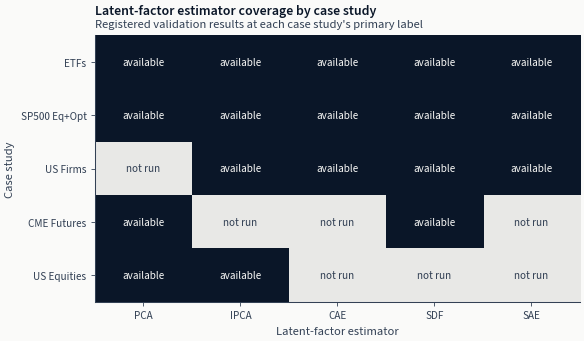

In [7]:
coverage_values = coverage.select(ESTIMATORS).to_numpy()
coverage_cmap = ListedColormap([COLORS["silver_muted"], COLORS["blue"]])
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.imshow(coverage_values, cmap=coverage_cmap, vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(ESTIMATORS)), [ESTIMATOR_NAMES[e] for e in ESTIMATORS])
ax.set_yticks(range(coverage.height), coverage["case_study"].to_list())
ax.set_xlabel("Latent-factor estimator")
ax.set_ylabel("Case study")
for row in range(coverage.height):
    for col in range(len(ESTIMATORS)):
        label = "available" if coverage_values[row, col] else "not run"
        color = COLORS["silver"] if coverage_values[row, col] else COLORS["neutral"]
        ax.text(col, row, label, ha="center", va="center", fontsize=8, color=color)
add_message_title(
    ax,
    "Latent-factor estimator coverage by case study",
    subtitle="Registered validation results at each case study's primary label",
)
show_with_alt(
    fig,
    "Grid with one row per case study and one column per latent-factor estimator (PCA, "
    "IPCA, CAE, SDF, SAE). Each cell is shaded dark where a validation result is "
    "registered and pale where it is not, and carries the word 'available' or 'not run'. "
    "Some rows are filled across every column and at least one has only two filled "
    "cells.",
)

## 2. Highest mean daily IC by case study

Selection and reporting use the same statistic: Spearman rank IC is computed
within each decision date and then averaged over dates. The error bars are
the registry's HAC 95% intervals, with lags that reflect the label horizon.

In [8]:
latent_winners = collect_rank1_per_cs(qualifying_case_studies, family=FAMILY).with_columns(
    estimator=pl.col("config_name").replace_strict(
        ESTIMATOR_NAMES,
        default=pl.col("config_name").str.to_uppercase(),
    )
)
latent_winners = latent_winners.sort("ic_mean_daily")
print("Highest-IC latent estimator per case study (primary label, validation):")
for winner in latent_winners.sort("ic_mean_daily", descending=True).iter_rows(named=True):
    print(
        f"  {winner['short_name']:<14} {winner['estimator']:<5} "
        f"IC={winner['ic_mean_daily']:+.4f} "
        f"[{winner['ic_ci_lo']:+.4f}, {winner['ic_ci_hi']:+.4f}]"
    )

Highest-IC latent estimator per case study (primary label, validation):
  ETFs           CAE   IC=+0.0889 [+0.0386, +0.1393]
  CME Futures    SDF   IC=+0.0328 [+0.0046, +0.0609]
  US Equities    IPCA  IC=+0.0184 [+0.0145, +0.0223]
  US Firms       SDF   IC=+0.0159 [-0.0060, +0.0377]
  SP500 Eq+Opt   SAE   IC=+0.0112 [-0.0144, +0.0367]


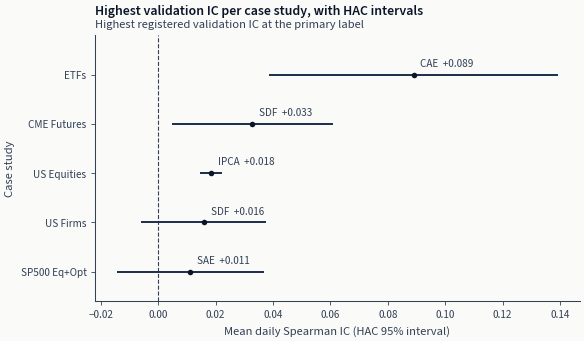

In [9]:
names = latent_winners["short_name"].to_list()
means = latent_winners["ic_mean_daily"].to_numpy()
lower = means - latent_winners["ic_ci_lo"].to_numpy()
upper = latent_winners["ic_ci_hi"].to_numpy() - means
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.errorbar(
    means,
    range(len(names)),
    xerr=np.vstack([lower, upper]),
    fmt="o",
    color=COLORS["blue"],
    ecolor=COLORS["slate"],
    capsize=3,
)
for y, row in enumerate(latent_winners.iter_rows(named=True)):
    ax.annotate(
        f"{row['estimator']}  {row['ic_mean_daily']:+.3f}",
        (row["ic_mean_daily"], y),
        xytext=(5, 6),
        textcoords="offset points",
        fontsize=8,
    )
ax.set_yticks(range(len(names)), names)
ax.set_ylim(-0.6, len(names) - 1 + 0.8)
ax.set_xlabel("Mean daily Spearman IC (HAC 95% interval)")
ax.set_ylabel("Case study")
zero_line(ax, axis="x")
add_message_title(
    ax,
    "Highest validation IC per case study, with HAC intervals",
    subtitle="Highest registered validation IC at the primary label",
)
show_with_alt(
    fig,
    "Horizontal error-bar chart with one row per case study, ordered so the highest mean "
    "daily Spearman IC is at the top. Each row is a point with its HAC 95% interval, "
    "annotated with the leading estimator's name and its IC, against a dashed line at "
    "zero. The intervals are wide relative to the gaps between panels, and the "
    "lowest-scoring rows have intervals that reach across zero.",
)

The printed table above names the leading estimator on each panel and the
figure shows the same values with their HAC intervals. No single estimator
leads everywhere. Read the intervals before the ordering: where an interval
spans zero, that panel's leader is not separated from no ranking skill at
all, and which estimator ranks best is a property of the panel and the
prediction target rather than of the estimator alone.

## 3. Estimators on one panel

Holding the dataset and the target fixed at the US Firms panel and its
primary label removes two sources of difference from the comparison. What
remains is not the training objective alone: IPCA's exposures are linear in
the characteristics, the CAE's are a neural map, and the SDF and SAE differ
again in structure and in how each is fitted. The comparison is between
estimators, not between objectives holding everything else equal.

In [10]:
us_firms_metrics = (
    load_metrics_from_registry(
        "us_firm_characteristics",
        label=PRIMARY_LABELS["us_firm_characteristics"],
        families=[FAMILY],
    )
    .filter(pl.col("ic_mean_daily").is_not_null())
    .sort("ic_mean_daily", descending=True)
    .group_by("config_name", maintain_order=True)
    .first()
    .with_columns(
        estimator=pl.col("config_name").replace_strict(
            ESTIMATOR_NAMES,
            default=pl.col("config_name").str.to_uppercase(),
        )
    )
    .sort("ic_mean_daily")
)
print("US Firms estimators by mean daily IC (best checkpoint each):")
for objective in us_firms_metrics.sort("ic_mean_daily", descending=True).iter_rows(named=True):
    print(
        f"  {objective['estimator']:<5} IC={objective['ic_mean_daily']:+.4f} "
        f"[{objective['ic_ci_lo']:+.4f}, {objective['ic_ci_hi']:+.4f}]"
    )

US Firms estimators by mean daily IC (best checkpoint each):
  SDF   IC=+0.0159 [-0.0060, +0.0377]
  SAE   IC=-0.0007 [-0.0128, +0.0114]
  CAE   IC=-0.0183 [-0.0496, +0.0129]
  IPCA  IC=-0.0297 [-0.0569, -0.0024]


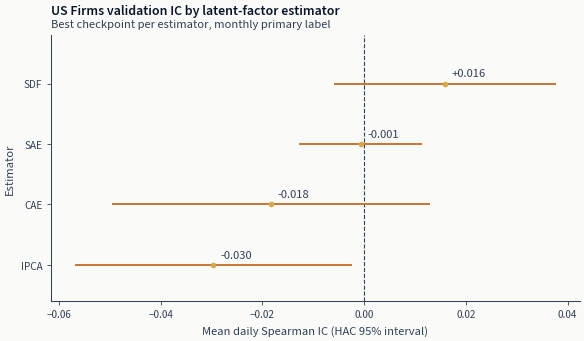

In [11]:
objective_names = us_firms_metrics["estimator"].to_list()
objective_means = us_firms_metrics["ic_mean_daily"].to_numpy()
objective_lo = objective_means - us_firms_metrics["ic_ci_lo"].to_numpy()
objective_hi = us_firms_metrics["ic_ci_hi"].to_numpy() - objective_means
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.errorbar(
    objective_means,
    range(len(objective_names)),
    xerr=np.vstack([objective_lo, objective_hi]),
    fmt="o",
    color=COLORS["amber"],
    ecolor=COLORS["copper"],
    capsize=3,
)
for y, value in enumerate(objective_means):
    ax.annotate(f"{value:+.3f}", (value, y), xytext=(5, 5), textcoords="offset points")
ax.set_yticks(range(len(objective_names)), objective_names)
ax.set_ylim(-0.6, len(objective_names) - 1 + 0.8)
ax.set_xlabel("Mean daily Spearman IC (HAC 95% interval)")
ax.set_ylabel("Estimator")
zero_line(ax, axis="x")
add_message_title(
    ax,
    "US Firms validation IC by latent-factor estimator",
    subtitle="Best checkpoint per estimator, monthly primary label",
)
show_with_alt(
    fig,
    "Horizontal error-bar chart with one row per latent-factor estimator on the US Firms "
    "panel, ordered with the highest mean daily Spearman IC at the top. Each point "
    "carries its value as a label and a HAC 95% interval, against a dashed line at zero. "
    "Most of the intervals span zero; the lowest row is the one that lies entirely on the "
    "negative side.",
)

The printed ordering above is the result; the figure adds each estimator's
HAC interval to it. Those intervals overlap each other heavily, so the
estimators are separated far less than the point estimates suggest. It is a
validation comparison in any case, and it cannot attribute a difference to
any one of the things that differ between two estimators.

## 4. Latent factors versus supervised models

The registry identifies the highest mean daily IC within each supervised
family and then across families. For each selected pair, predictions are
inner-joined on the same timestamp-entity keys. Both model ICs and their
difference are recomputed within each date on that identical cross-section.

The HAC interval is conditional on validation-based model selection. It is a
paired stability diagnostic, not an unbiased post-selection hypothesis test.

A label's suffix determines the minimum dependence horizon. Monthly targets
use one monthly period; daily targets use their stated number of days.

In [12]:
def label_horizon(label: str) -> int:
    """Return the target horizon in its observation periods."""
    suffix = label.rsplit("_", maxsplit=1)[-1]
    digits = "".join(character for character in suffix if character.isdigit())
    return max(1, int(digits)) if digits else 1

CME prediction artifacts use the canonical `product` identifier in the
supervised pipeline and `symbol` in the older latent artifact. Both identify
the same futures contract, so the loader normalizes either field to `entity`
only inside this comparison frame.

In [13]:
def selected_predictions(case_study: str, row: dict, score_name: str) -> pl.DataFrame:
    """Load one selected validation prediction set with a common entity key.

    Addressed by `prediction_hash`, which is the identity, rather than by the four
    attributes that describe it. They are not a key: refitting a configuration under a
    changed estimator parameter writes a second prediction set with the same family, label,
    configuration and checkpoint, and `sp500_equity_option_analytics` has four generations
    of every `latent_factors/sae` checkpoint. Selecting on the attributes returned all four,
    so every (timestamp, entity) pair appeared four times and the guard below fired - which
    is what it is for, but the fix is to ask for the row that was selected.
    """
    frame = load_predictions(
        case_study,
        prediction_hash=row["prediction_hash"],
        split="validation",
    )
    entity = "product" if "product" in frame.columns else "symbol"
    selected = frame.select(
        pl.col("timestamp").cast(pl.Datetime("us")),
        pl.col(entity).cast(pl.Utf8).alias("entity"),
        pl.col("y_true").alias(f"{score_name}_target"),
        pl.col("y_score").alias(f"{score_name}_score"),
    )
    if selected.height != selected.unique(["timestamp", "entity"]).height:
        raise ValueError(f"Duplicate validation keys for {case_study} {score_name}")
    return selected

The paired calculation ranks both scores and the common target within each
date. Pearson correlation of those within-date ranks is Spearman IC. The
function returns the complete, time-sorted daily series for independent
uncertainty calculation.

In [14]:
def paired_daily_ic(latent: pl.DataFrame, supervised: pl.DataFrame) -> pl.DataFrame:
    """Compute paired per-date IC after exact timestamp-entity alignment."""
    joined = latent.join(supervised, on=["timestamp", "entity"], how="inner")
    target_gap = joined.select(
        (pl.col("latent_target") - pl.col("supervised_target")).abs().max()
    ).item()
    # Two recordings of the same label agree only to float32 resolution at the target's own
    # scale: a prediction artifact can be written through a float32 stage and its partner not.
    # The bound is therefore relative, not the absolute 1e-10 that used to stand here - that
    # one passed wherever targets were small and failed on us_firm_characteristics, whose
    # monthly returns reach 7.0, at a gap of 2.1e-07. Measured across the four pairs this
    # notebook forms: relative gaps of 0, 1.8e-08, 3.0e-08 and 4.2e-08 against a float32 eps
    # of 1.19e-07. It still separates float noise from the thing this guard exists to catch,
    # two different labels joined on the same keys, which disagree by 1.4 to 6.0.
    magnitude = joined.select(
        pl.max_horizontal(
            pl.col("latent_target").abs().max(), pl.col("supervised_target").abs().max()
        )
    ).item()
    tolerance = float(np.finfo(np.float32).eps) * max(1.0, abs(magnitude or 0.0))
    if target_gap is None or target_gap > tolerance:
        raise ValueError(
            f"Aligned targets disagree: maximum gap {target_gap} exceeds {tolerance:.3g} "
            f"at a target magnitude of {magnitude}"
        )
    ranked = joined.with_columns(
        pl.col("latent_score").rank(method="average").over("timestamp").alias("latent_rank"),
        pl.col("supervised_score")
        .rank(method="average")
        .over("timestamp")
        .alias("supervised_rank"),
        pl.col("latent_target").rank(method="average").over("timestamp").alias("target_rank"),
    )
    return (
        # No maintain_order: the chain ends in .sort("timestamp") and timestamp is the
        # only group key, so it is unique after the aggregation and the sort determines
        # the order completely. Pinning a group_by whose order is already decided reads
        # to the next person like the Chapter 13 defect, where ten unordered group_bys
        # permuted five rendered cells between executions, and this was never that.
        ranked.group_by("timestamp")
        .agg(
            pl.len().alias("n_obs"),
            pl.corr("latent_rank", "target_rank").alias("latent_ic"),
            pl.corr("supervised_rank", "target_rank").alias("supervised_ic"),
        )
        .filter(pl.col("n_obs") >= 5)
        .with_columns((pl.col("latent_ic") - pl.col("supervised_ic")).alias("delta"))
        .drop_nulls(["latent_ic", "supervised_ic", "delta"])
        .sort("timestamp")
    )

Select the strongest supervised registry row for each panel using
`ic_mean_daily`, the same column used for the latent selections and all
displayed rankings.

In [15]:
supervised_winners = {}
for case_study in qualifying_case_studies:
    metrics = load_metrics_from_registry(
        case_study,
        label=PRIMARY_LABELS[case_study],
        families=list(SUPERVISED_FAMILIES),
    ).filter(pl.col("ic_mean_daily").is_not_null())
    supervised_winners[case_study] = metrics.sort("ic_mean_daily", descending=True).row(
        0, named=True
    )

In [16]:
comparison_rows = []
paired_series = {}
for latent_row in latent_winners.iter_rows(named=True):
    case_study = latent_row["case_study"]
    supervised_row = supervised_winners[case_study]
    latent = selected_predictions(case_study, latent_row, "latent")
    supervised = selected_predictions(case_study, supervised_row, "supervised")
    daily = paired_daily_ic(latent, supervised)
    paired_series[case_study] = daily
    uncertainty = compute_ic_uncertainty(
        daily.select(pl.col("delta").alias("ic")),
        horizon=label_horizon(latent_row["label"]),
        n_boot=N_BOOT,
        seed=SEED,
    )
    comparison_rows.append(
        {
            "case_study": case_study,
            "short_name": latent_row["short_name"],
            "latent_name": latent_row["estimator"],
            "supervised_name": FAMILY_NAMES[supervised_row["family"]],
            "latent_ic": daily["latent_ic"].mean(),
            "supervised_ic": daily["supervised_ic"].mean(),
            "delta": uncertainty["mean_ic"],
            "delta_lo": uncertainty["ci_hac_lower"],
            "delta_hi": uncertainty["ci_hac_upper"],
            "n_dates": uncertainty["n_days"],
            "n_common": latent.join(supervised, on=["timestamp", "entity"], how="inner").height,
        }
    )
comparison = pl.DataFrame(comparison_rows).sort("delta")
print("Latent minus supervised, paired on common dates and entities:")
for pair in comparison.sort("delta", descending=True).iter_rows(named=True):
    print(
        f"  {pair['short_name']:<14} {pair['latent_name']:<5} vs "
        f"{pair['supervised_name']:<14} delta={pair['delta']:+.4f} "
        f"[{pair['delta_lo']:+.4f}, {pair['delta_hi']:+.4f}] "
        f"dates={pair['n_dates']}, rows={pair['n_common']:,}"
    )

Latent minus supervised, paired on common dates and entities:
  ETFs           CAE   vs GBM            delta=+0.0343 [+0.0079, +0.0607] dates=1995, rows=188,473
  SP500 Eq+Opt   SAE   vs TabM           delta=+0.0014 [-0.0292, +0.0320] dates=497, rows=194,813
  CME Futures    SDF   vs Deep learning  delta=-0.0102 [-0.0468, +0.0264] dates=1285, rows=38,262
  US Equities    IPCA  vs GBM            delta=-0.0127 [-0.0177, -0.0077] dates=4031, rows=7,170,323
  US Firms       SDF   vs GBM            delta=-0.0677 [-0.0995, -0.0360] dates=110, rows=252,008


The upper panel compares paired-sample mean IC. The lower panel isolates the
latent-minus-supervised difference with its HAC interval. Point estimates
left of zero favor the selected supervised model.

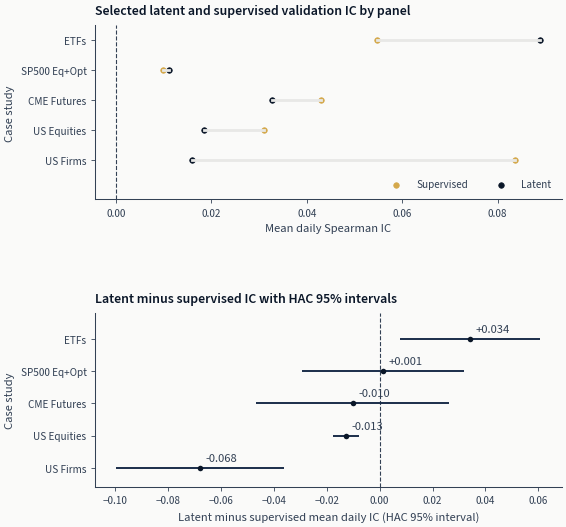

In [17]:
fig, axes = plt.subplots(2, 1, figsize=FIGSIZE["dashboard_2x2"], constrained_layout=False)
fig.subplots_adjust(hspace=0.65, left=0.18, right=0.98, top=0.94, bottom=0.1)
y = np.arange(comparison.height)
for idx, row in enumerate(comparison.iter_rows(named=True)):
    axes[0].plot(
        [row["supervised_ic"], row["latent_ic"]],
        [idx, idx],
        color=COLORS["silver_muted"],
        linewidth=2,
    )
axes[0].scatter(comparison["supervised_ic"], y, color=COLORS["amber"], label="Supervised")
axes[0].scatter(comparison["latent_ic"], y, color=COLORS["blue"], label="Latent")
axes[0].set_yticks(y, comparison["short_name"].to_list())
axes[0].set_xlabel("Mean daily Spearman IC")
axes[0].set_ylabel("Case study")
# The legend's own markers are the same shapes as the data, so it needs empty axes
# rather than the bottom row to sit on.
axes[0].set_ylim(-1.3, comparison.height - 1 + 0.5)
axes[0].legend(loc="lower right", ncol=2)
zero_line(axes[0], axis="x")
add_message_title(axes[0], "Selected latent and supervised validation IC by panel")

delta = comparison["delta"].to_numpy()
delta_lo = delta - comparison["delta_lo"].to_numpy()
delta_hi = comparison["delta_hi"].to_numpy() - delta
axes[1].errorbar(
    delta,
    y,
    xerr=np.vstack([delta_lo, delta_hi]),
    fmt="o",
    color=COLORS["blue"],
    ecolor=COLORS["slate"],
    capsize=3,
)
for idx, value in enumerate(delta):
    axes[1].annotate(f"{value:+.3f}", (value, idx), xytext=(4, 5), textcoords="offset points")
axes[1].set_yticks(y, comparison["short_name"].to_list())
axes[1].set_ylim(-0.6, comparison.height - 1 + 0.8)
axes[1].set_xlabel("Latent minus supervised mean daily IC (HAC 95% interval)")
axes[1].set_ylabel("Case study")
zero_line(axes[1], axis="x")
add_message_title(axes[1], "Latent minus supervised IC with HAC 95% intervals")
show_with_alt(
    fig,
    "Two stacked panels, one row per case study in both. The upper panel places two "
    "points on a shared mean-daily-IC axis for each case study, amber for the selected "
    "supervised model and navy for the selected latent model, joined by a light line, "
    "against a dashed zero line; on some case studies the two sit close together and on "
    "others they are clearly apart. The lower panel plots the latent-minus-supervised "
    "difference for each case study with its HAC 95% interval and a value label, against "
    "a dashed zero line. Some intervals span zero and some lie wholly to one side of it, "
    "and each point carries its value as a label.",
)

Latent models lead on some panels and lag on others. The paired construction
makes this comparison interpretable: each difference uses the same assets on
the same dates. The intervals still reflect validation uncertainty after that
selection and therefore should not be read as holdout tests.

## 5. Neural estimator agreement on US Firms

Low average rank correlation means two estimators order firms differently,
which can support ensemble diversification. Correlations are computed within
month first and then averaged, so months with larger cross-sections do not
dominate the diagnostic.

This helper aligns a selected pair on common observations and returns the
mean of its monthly Spearman correlation series.

In [18]:
def mean_daily_score_correlation(left: pl.DataFrame, right: pl.DataFrame) -> float:
    """Average per-date Spearman correlation on common prediction rows."""
    joined = left.join(right, on=["timestamp", "entity"], how="inner")
    ranked = joined.with_columns(
        pl.col("left_score").rank(method="average").over("timestamp").alias("left_rank"),
        pl.col("right_score").rank(method="average").over("timestamp").alias("right_rank"),
    )
    daily = (
        # Same as `paired_daily_ic` above: unique key, terminal sort, and the caller
        # takes a mean, which no ordering can move.
        ranked.group_by("timestamp")
        .agg(pl.len().alias("n_obs"), pl.corr("left_rank", "right_rank").alias("correlation"))
        .filter(pl.col("n_obs") >= 5)
        .drop_nulls("correlation")
        .sort("timestamp")
    )
    return float(daily["correlation"].mean())

In [19]:
neural_metrics = (
    load_metrics_from_registry(
        "us_firm_characteristics",
        label=PRIMARY_LABELS["us_firm_characteristics"],
        families=[FAMILY],
    )
    .filter(pl.col("config_name").is_in(["cae", "sdf", "sae"]))
    .filter(pl.col("ic_mean_daily").is_not_null())
    .sort("ic_mean_daily", descending=True)
    .group_by("config_name", maintain_order=True)
    .first()
)
neural_predictions = {}
for row in neural_metrics.iter_rows(named=True):
    frame = selected_predictions("us_firm_characteristics", row, "left")
    neural_predictions[row["config_name"]] = frame.select("timestamp", "entity", "left_score")

In [20]:
neural_names = sorted(neural_predictions)
agreement = np.eye(len(neural_names))
for i, left_name in enumerate(neural_names):
    for j in range(i + 1, len(neural_names)):
        right_name = neural_names[j]
        left = neural_predictions[left_name]
        right = neural_predictions[right_name].rename({"left_score": "right_score"})
        agreement[i, j] = mean_daily_score_correlation(left, right)
        agreement[j, i] = agreement[i, j]

In [21]:
off_diagonal = agreement[np.triu_indices(len(neural_names), k=1)]
print(
    f"Neural estimator agreement on US Firms: {len(off_diagonal)} pairs, mean monthly "
    f"rank correlation {off_diagonal.min():+.2f} to {off_diagonal.max():+.2f}"
)

Neural estimator agreement on US Firms: 3 pairs, mean monthly rank correlation +0.26 to +0.41


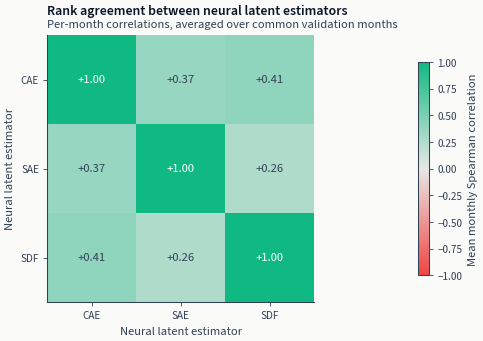

In [22]:
correlation_cmap = LinearSegmentedColormap.from_list("ml4t_diverging", ml4t_diverging())
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
image = ax.imshow(agreement, cmap=correlation_cmap, vmin=-1, vmax=1)
display_names = [ESTIMATOR_NAMES[name] for name in neural_names]
ax.set_xticks(range(len(display_names)), display_names)
ax.set_yticks(range(len(display_names)), display_names)
ax.set_xlabel("Neural latent estimator")
ax.set_ylabel("Neural latent estimator")
for row in range(len(display_names)):
    for col in range(len(display_names)):
        value = agreement[row, col]
        ax.text(
            col,
            row,
            f"{value:+.2f}",
            ha="center",
            va="center",
            color="white" if abs(value) > 0.6 else COLORS["neutral"],
        )
colorbar = fig.colorbar(image, ax=ax, shrink=0.8)
colorbar.set_label("Mean monthly Spearman correlation")
add_message_title(
    ax,
    "Rank agreement between neural latent estimators",
    subtitle="Per-month correlations, averaged over common validation months",
)
show_with_alt(
    fig,
    "Square heatmap of the mean monthly Spearman correlation between the neural latent "
    "estimators, with the same estimator names on both axes, a diverging color scale from "
    "-1 to 1, a colorbar, and every cell labeled. The diagonal is fixed at +1.00 by "
    "construction. The off-diagonal pairs all sit well short of one, in the low positive "
    "range.",
)

The printed off-diagonal range is well short of one, so the three neural
estimators do not merely repackage the same ranking. That supports testing them as
separate ensemble inputs. Chapter 20 makes the portfolio decision, under the
holdout protocol defined there.

## Key takeaways

- Registry coverage is uneven, so missing cells are not performance results.
- No latent estimator leads every panel. Which one leads where is printed in
  Section 2 and moves with the registry snapshot.
- With the panel and target held fixed the estimators still differ in
  architecture and fitting, and their intervals overlap heavily, so Section 3
  orders them without attributing the ordering to any one difference.
- Paired per-date comparisons show that neither latent nor supervised models
  dominate everywhere. These are post-selection validation diagnostics.
- The neural estimators produce distinct monthly firm rankings, making model
  diversity a testable input to Chapter 20 rather than an assumption.

**Next**: Chapter 15 studies causal effects; Chapter 20 evaluates how these
predictive signals combine under the holdout protocol defined there.